In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plotting style
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

# Load the data
df = pd.read_csv('loan_data.csv')


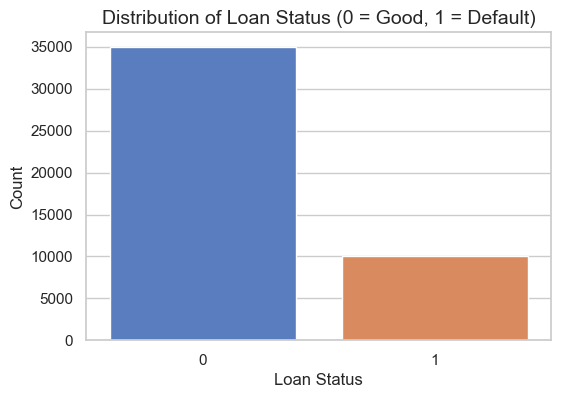

Percentage of class distribution:
loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, hue='loan_status', legend=False)
plt.title('Distribution of Loan Status (0 = Good, 1 = Default)', fontsize=14)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

print("Percentage of class distribution:")
print(df['loan_status'].value_counts(normalize=True) * 100)


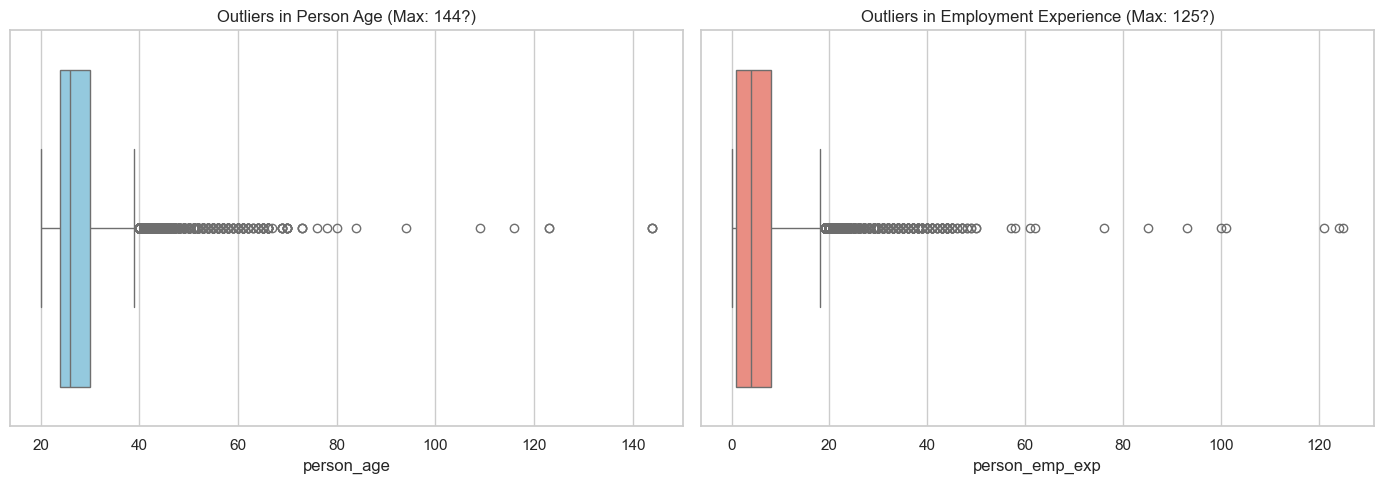

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Boxplot
sns.boxplot(ax=axes[0], x=df['person_age'], color='skyblue')
axes[0].set_title('Outliers in Person Age (Max: 144?)')

# Employment Experience Boxplot
sns.boxplot(ax=axes[1], x=df['person_emp_exp'], color='salmon')
axes[1].set_title('Outliers in Employment Experience (Max: 125?)')

plt.tight_layout()
plt.show()


C:\Users\rayph\AppData\Local\Temp\ipykernel_11688\2395394446.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)


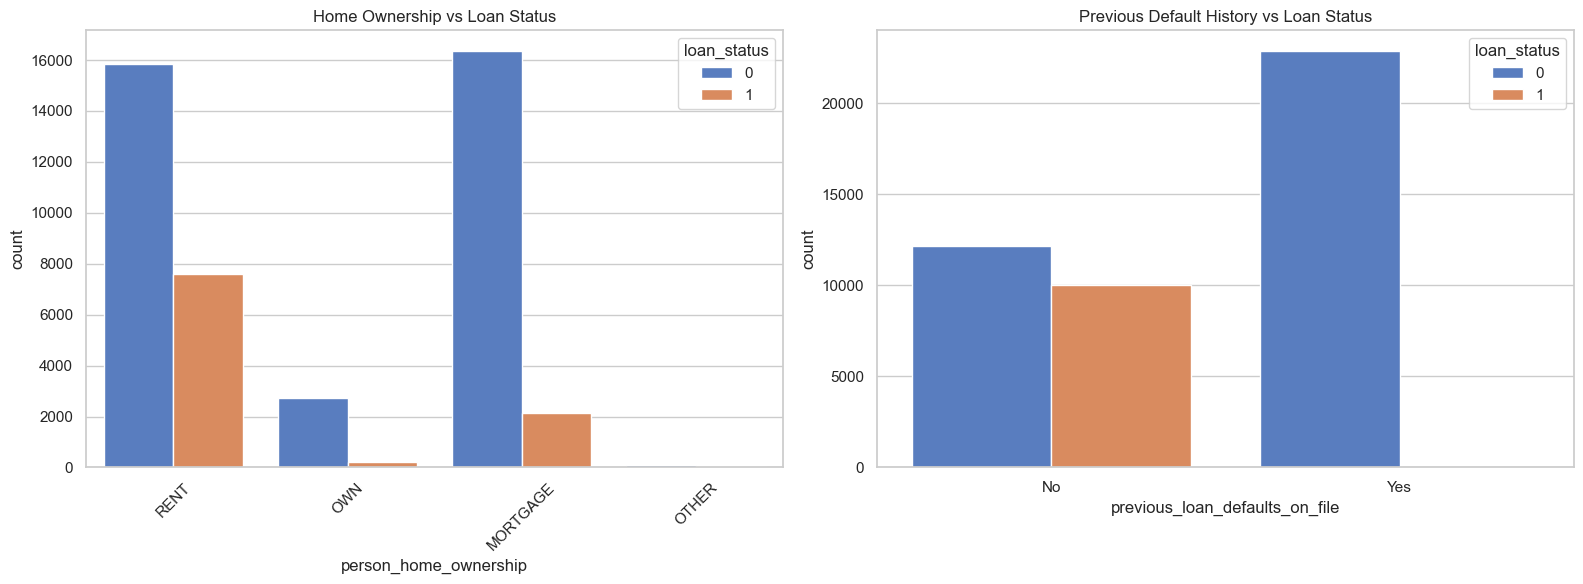

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Home Ownership vs Loan Status
sns.countplot(ax=axes[0], x='person_home_ownership', hue='loan_status', data=df)
axes[0].set_title('Home Ownership vs Loan Status')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Previous Default vs Loan Status
sns.countplot(ax=axes[1], x='previous_loan_defaults_on_file', hue='loan_status', data=df)
axes[1].set_title('Previous Default History vs Loan Status')

plt.tight_layout()
plt.show()


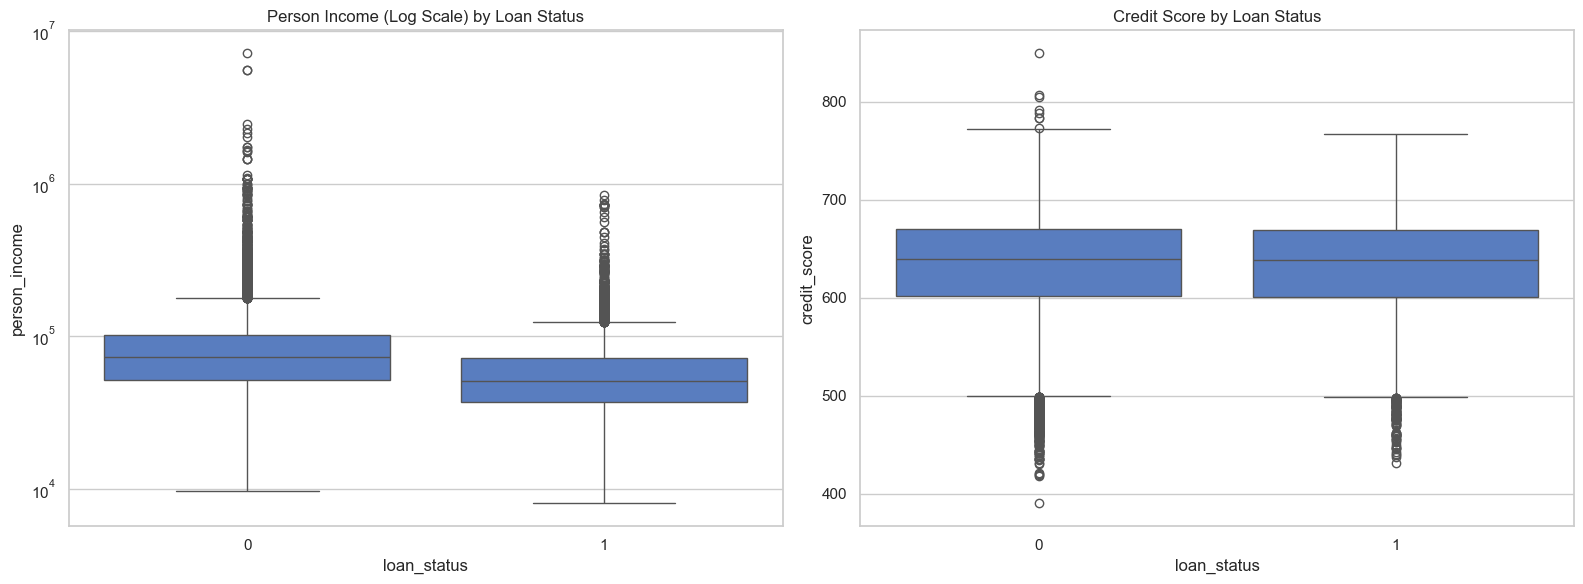

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Income vs Loan Status (Using Log Scale because income is heavily skewed)
sns.boxplot(ax=axes[0], x='loan_status', y='person_income', data=df)
axes[0].set_yscale('log')
axes[0].set_title('Person Income (Log Scale) by Loan Status')

# Credit Score vs Loan Status
sns.boxplot(ax=axes[1], x='loan_status', y='credit_score', data=df)
axes[1].set_title('Credit Score by Loan Status')

plt.tight_layout()
plt.show()


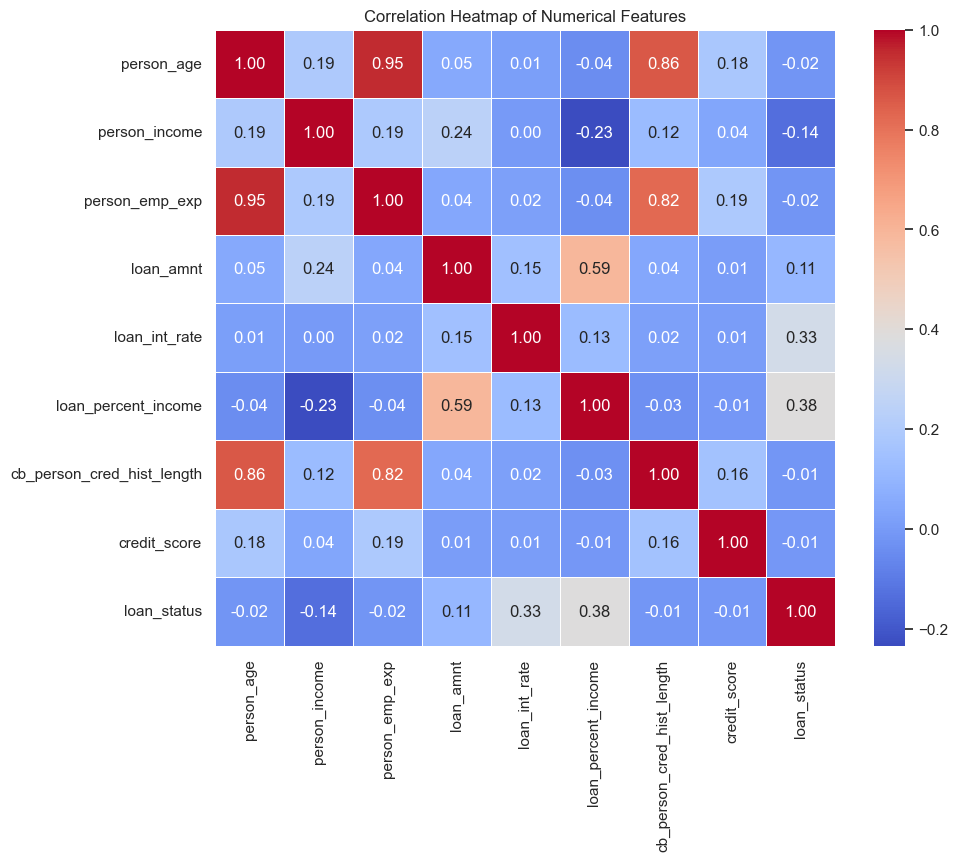

In [7]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()
